# Instantaneous surface velocity by age and diagnosis

This notebook compares **direct-mesh cocycle**, **latent cocycle**, and the
three-member **LAMM ensemble** on the validation cohort. INR is included in a
strict shared subset. Historical latent ODE and BrainODE results are shown in a
separate section because their data and evaluation protocol differ.

The continuous-time derivative is not observed by MRI. The line labelled
**Observed reference** is the derivative of a smooth trajectory fitted through
each subject's registered longitudinal meshes after removing residual rigid
motion. It is therefore the best available longitudinal reference, not a
directly measured physical ground truth.


## Load completed results

This notebook performs no model inference and does not touch the test split. It
only reads the already validated CSV tables and PNG figures.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

RESULT_DIR = Path('/mnt/bulk10tb/Deep3DComp/ADNI_1_LHipp/task4_all_flow_visual_analysis_v1/age_velocity_all_methods_v1')
FIGURE_DIR = RESULT_DIR / "figures"
TABLE_DIR = RESULT_DIR / "tables"

with (RESULT_DIR / "summary.json").open() as f:
    manifest = json.load(f)
full = pd.read_csv(TABLE_DIR / "full_cohort_age_summary.csv")
strict = pd.read_csv(TABLE_DIR / "strict_common_age_summary.csv")
legacy = pd.read_csv(TABLE_DIR / "legacy_age_summary.csv")

assert manifest["status"] == "complete"
assert manifest["split"] == "val"
assert manifest["test_data_loaded"] is False
print("Validated result:", manifest["status"])
print("Full matched cohort: 269 visits from 61 subjects")
print("Strict INR-shared cohort: 100 visits from 20 subjects")


Validated result: complete
Full matched cohort: 269 visits from 61 subjects
Strict INR-shared cohort: 100 visits from 20 subjects


## What velocity each model supplies

- **Mesh Spiral / Mesh Adaptive:** the network outputs a zero-horizon velocity
  at every corresponding template vertex. This is a direct surface-space field.
- **Latent PCA / Spiral / Adaptive:** the network outputs the instantaneous
  derivative of its latent state. Decoder differentiation maps that derivative
  to the corresponding surface vertices.
- **LAMM N=3:** the three trained latent-flow members are differentiated and
  decoded independently; their three surface velocity vectors are averaged.
- **Latent INR:** the latent derivative is propagated through the implicit SDF
  decoder. An implicit level set determines only normal surface motion, so no
  unsupported tangential INR velocity is invented.

All surface quantities below are in millimetres per year. Latent widths are
intentionally omitted from result labels.


In [2]:
counts = pd.DataFrame(manifest["method_counts"]).T
counts.index = [
    full.loc[full.method.eq(name), "method_label"].iloc[0]
    if full.method.eq(name).any()
    else strict.loc[strict.method.eq(name), "method_label"].iloc[0]
    for name in counts.index
]
display(counts.rename(columns={"subjects": "Subjects", "visits": "Visits"}))


,Subjects,Visits
LAMM N3,61,269
Latent Adaptive,61,269
Latent INR,20,100
Latent PCA,61,269
Latent Spiral,61,269
Mesh Adaptive,61,269
Mesh Spiral,61,269


## Metric 1 — velocity magnitude

**Speed** is the mean length of the vertex velocity vectors. It answers “how
much surface motion per year does the model produce?” but not whether that
motion points in the correct direction. A prediction below the observed line
is too static. Confidence bands are 95% intervals from resampling subjects,
which preserves the dependence among repeated visits.


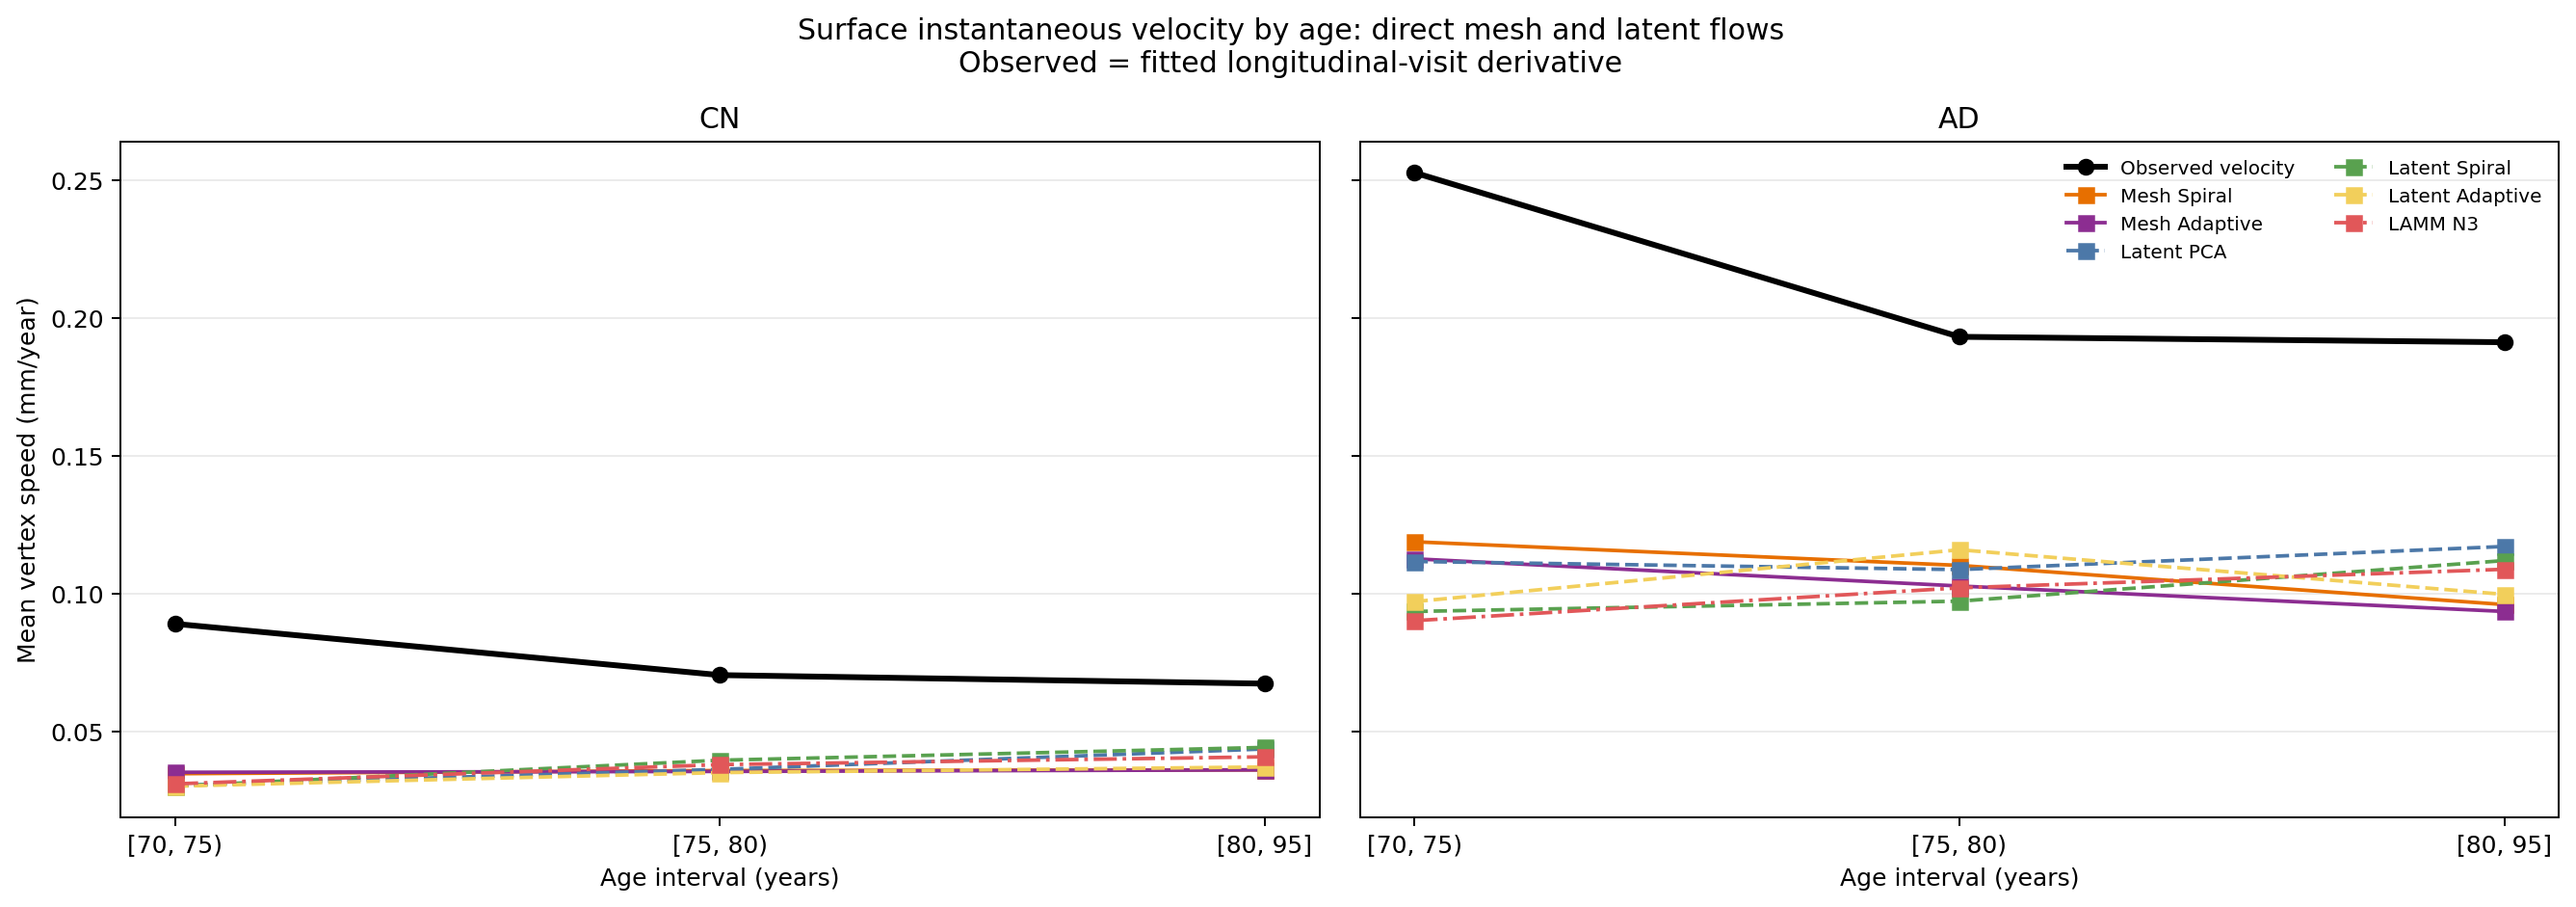

In [3]:
display(Image(filename=str(FIGURE_DIR / "full_cohort_speed_by_age.png")))


## Metric 2 — signed inward normal velocity

Each vertex velocity is projected onto the inward surface normal and then
averaged. Positive values mean inward motion/atrophy under this sign
convention; negative values mean outward motion. Unlike speed, this metric
distinguishes contraction from expansion, although tangential motion does not
contribute.


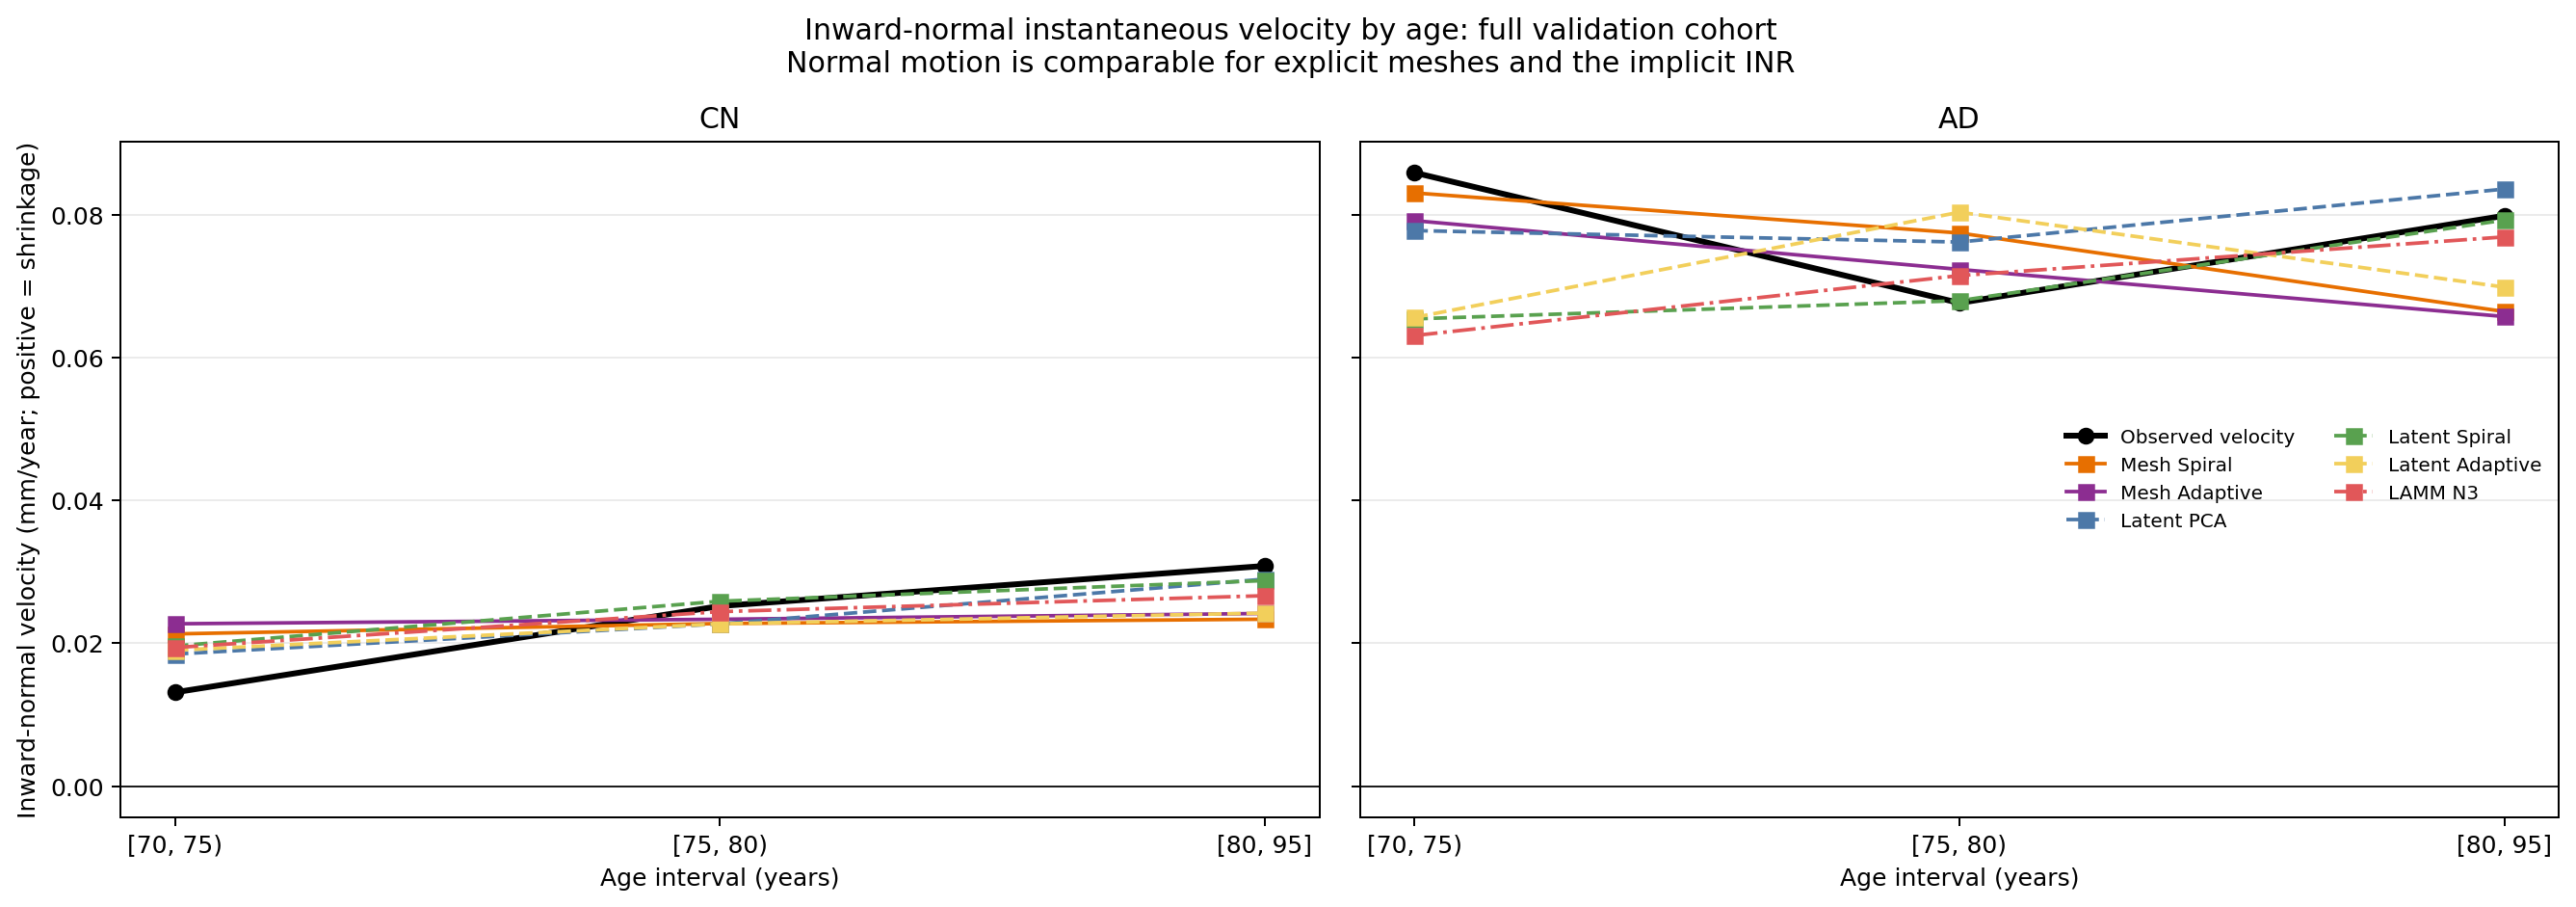

In [4]:
display(Image(filename=str(FIGURE_DIR / "full_cohort_inward_normal_by_age.png")))


## Metrics 3–5 — agreement with the observed reference

- **Normal error / zero prediction:** RMSE of the predicted versus observed
  normal velocity, divided by the RMSE obtained by predicting no motion.
  Values below 1 improve on a zero-velocity baseline; lower is better.
- **Normal correlation:** spatial Pearson correlation between predicted and
  observed normal velocities after weighted aggregation; higher is better.
- **Vector cosine:** directional agreement of full 3-D vertex velocities.
  1 is aligned, 0 is unrelated, and −1 is opposite.

These metrics complement speed: a method can predict a plausible magnitude
while placing change on the wrong part of the hippocampal surface.


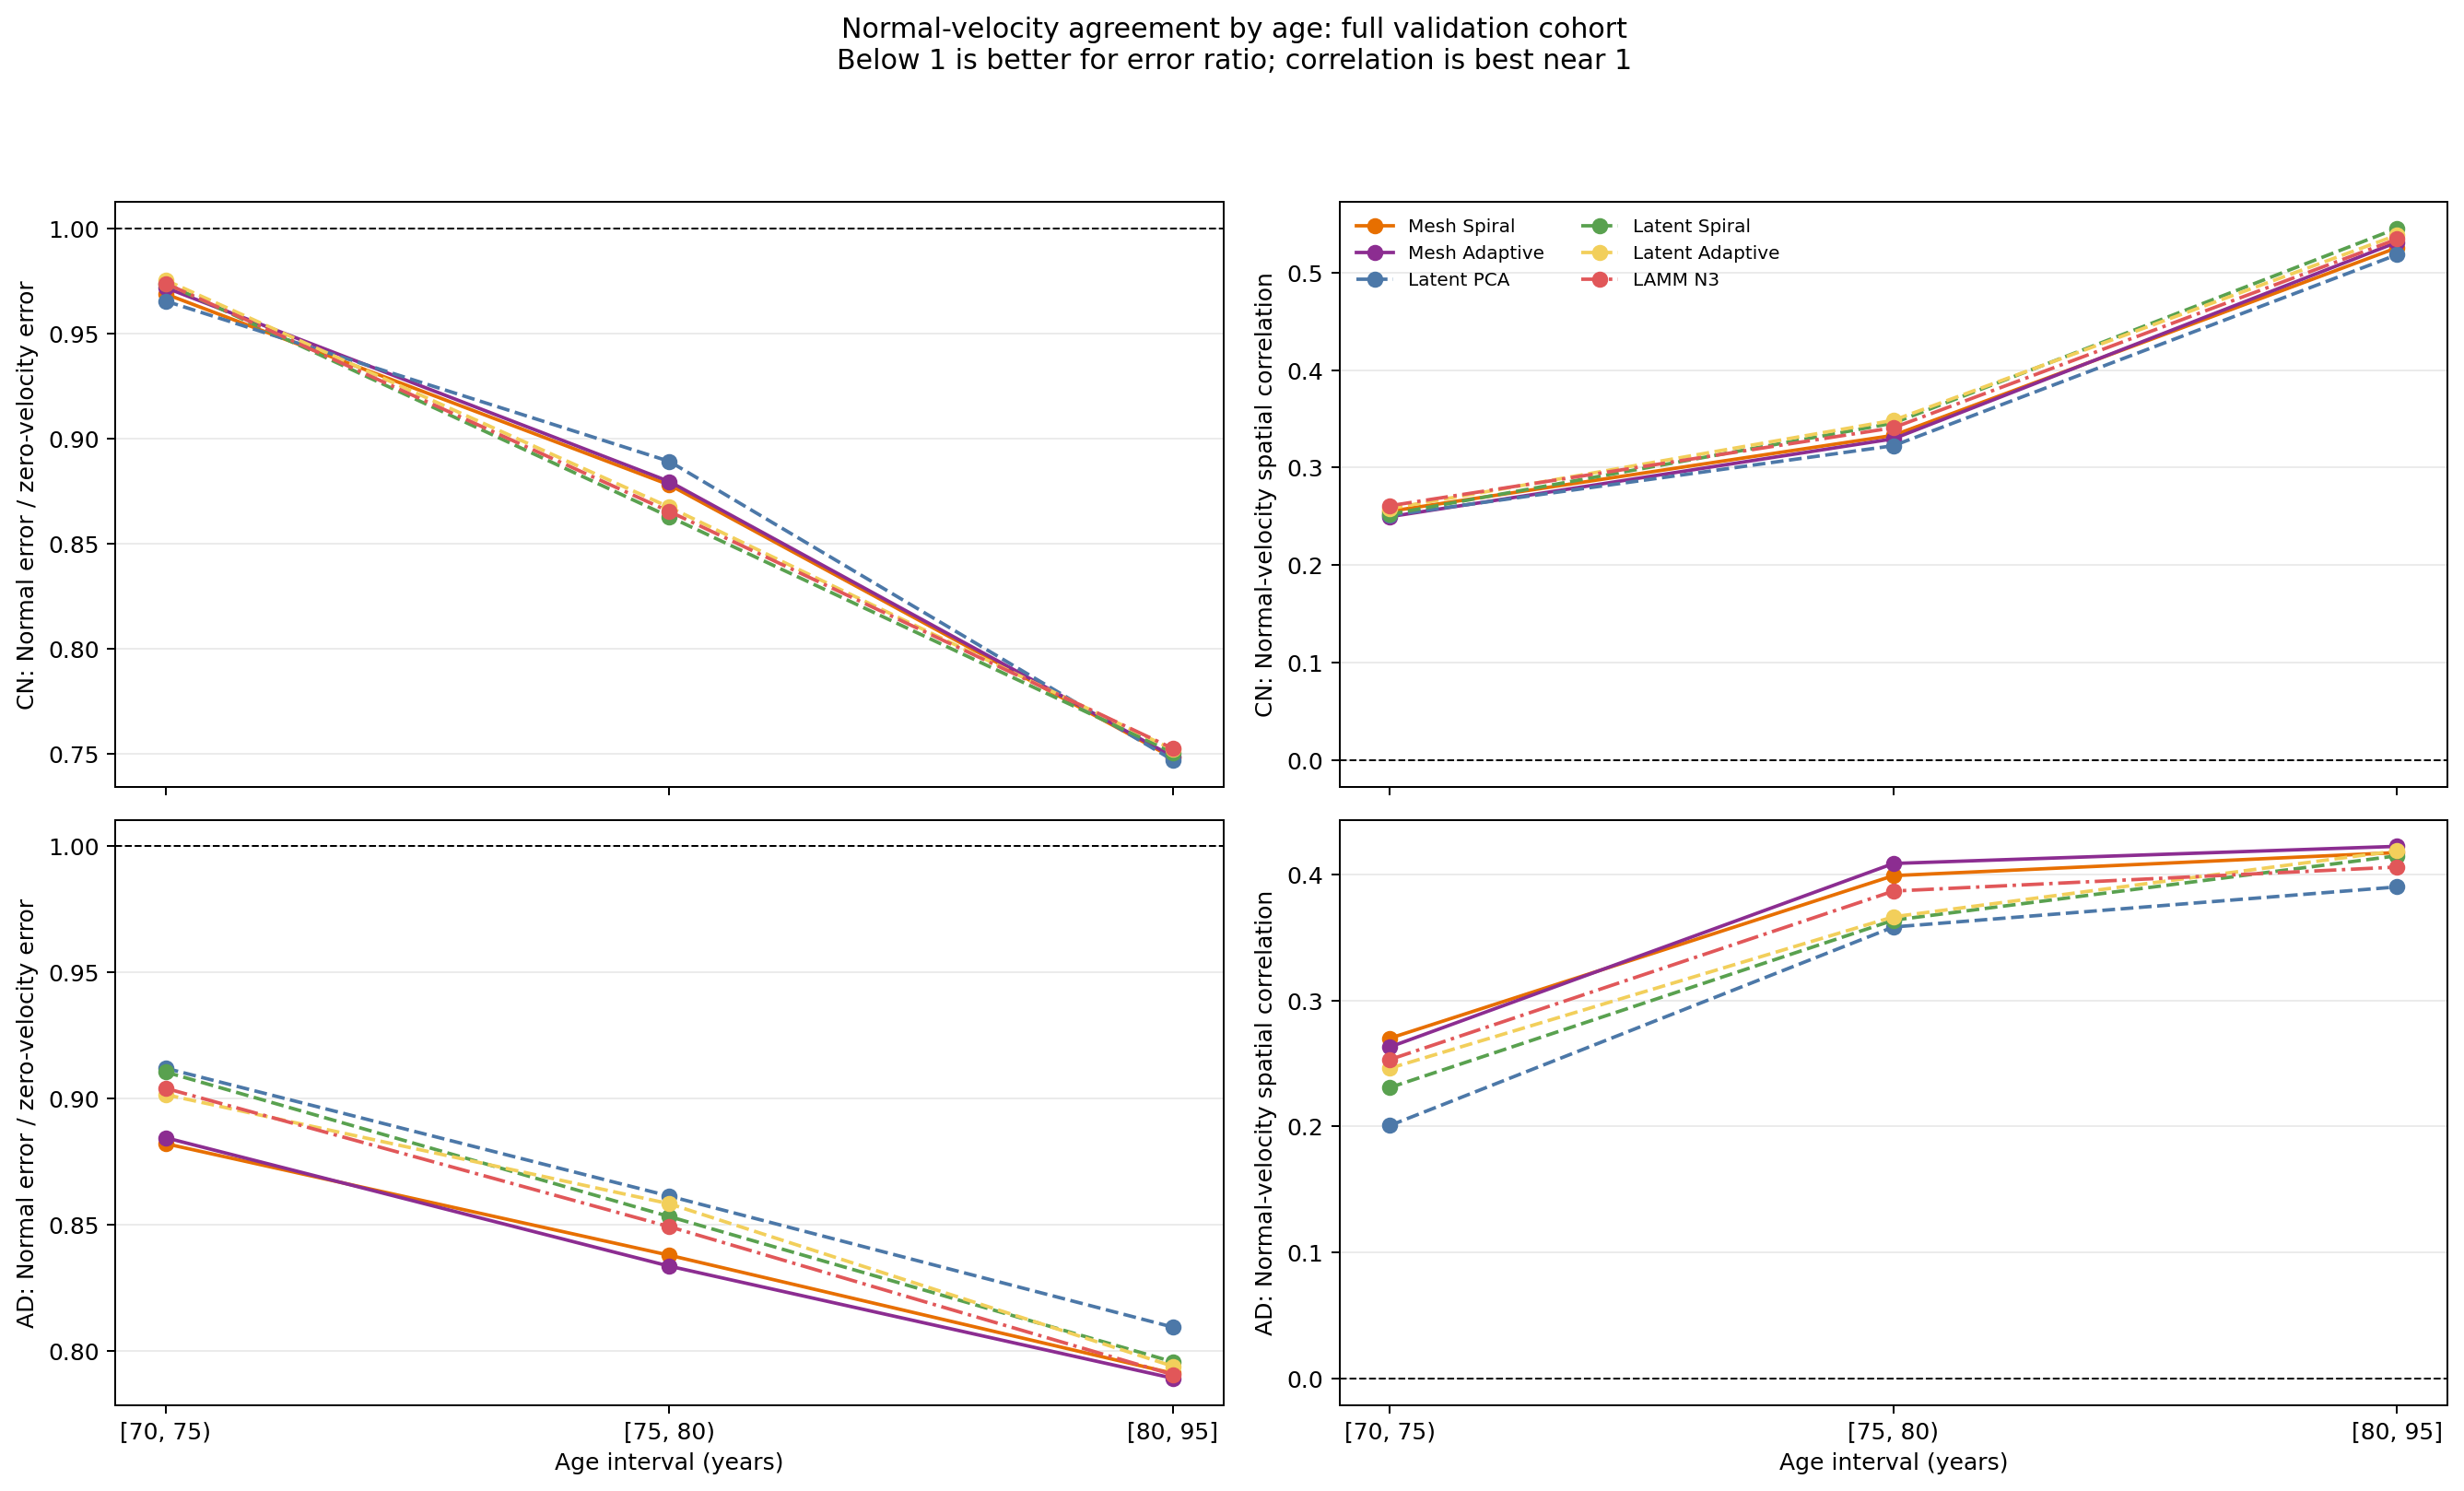

In [5]:
display(Image(filename=str(FIGURE_DIR / "full_cohort_normal_agreement_by_age.png")))


### Full-cohort numerical results

The table exposes the values underlying the figures. `Speed ratio` is predicted
speed divided by observed speed; 1 would match the reference magnitude.


In [6]:
cols = [
    "method_label", "diagnosis", "age_bin", "visits", "subjects",
    "predicted_speed_mm_per_year", "observed_speed_mm_per_year", "speed_ratio",
    "normal_error_to_zero_ratio", "normal_pearson", "vector_cosine",
]
display(full[cols].rename(columns={
    "method_label": "Method", "diagnosis": "Group", "age_bin": "Age",
    "visits": "Visits", "subjects": "Subjects",
    "predicted_speed_mm_per_year": "Predicted speed",
    "observed_speed_mm_per_year": "Observed speed", "speed_ratio": "Speed ratio",
    "normal_error_to_zero_ratio": "Normal error / zero prediction",
    "normal_pearson": "Normal correlation", "vector_cosine": "Vector cosine",
}).round(4))


,Method,Group,Age,Visits,Subjects,Predicted speed,Observed speed,Speed ratio,Normal error / zero prediction,Normal correlation,Vector cosine
0,Mesh Spiral,CN,"[70, 75)",57,17,0.0345,0.0889,0.3883,0.9688,0.2552,0.3328
1,Mesh Spiral,CN,"[75, 80)",61,21,0.0357,0.0703,0.5074,0.8780,0.3331,0.4636
2,Mesh Spiral,CN,"[80, 95]",48,14,0.0359,0.0672,0.5345,0.7482,0.5255,0.6445
3,Mesh Spiral,AD,"[70, 75)",29,10,0.1187,0.2527,0.4698,0.8822,0.2699,0.4315
4,Mesh Spiral,AD,"[75, 80)",26,8,0.1101,0.1931,0.5704,0.8380,0.3990,0.5336
5,Mesh Spiral,AD,"[80, 95]",20,6,0.0959,0.1911,0.5018,0.7912,0.4172,0.6227
6,Mesh Adaptive,CN,"[70, 75)",57,17,0.0350,0.0889,0.3941,0.9718,0.2497,0.3293
7,Mesh Adaptive,CN,"[75, 80)",61,21,0.0354,0.0703,0.5027,0.8796,0.3295,0.4623
8,Mesh Adaptive,CN,"[80, 95]",48,14,0.0359,0.0672,0.5344,0.7488,0.5311,0.6453
9,Mesh Adaptive,AD,"[70, 75)",29,10,0.1125,0.2527,0.4454,0.8846,0.2630,0.4271


## Strict shared cohort including INR

INR is available for fewer validation subjects, so adding it requires reducing
every method to exactly the same 20 subjects and 100 visits. These figures are
for an apples-to-apples INR comparison only. The oldest AD bin contains one
subject and must be treated as descriptive, not a stable population estimate.
For INR, agreement should be interpreted as normal-motion agreement because an
implicit surface does not identify tangential correspondence.


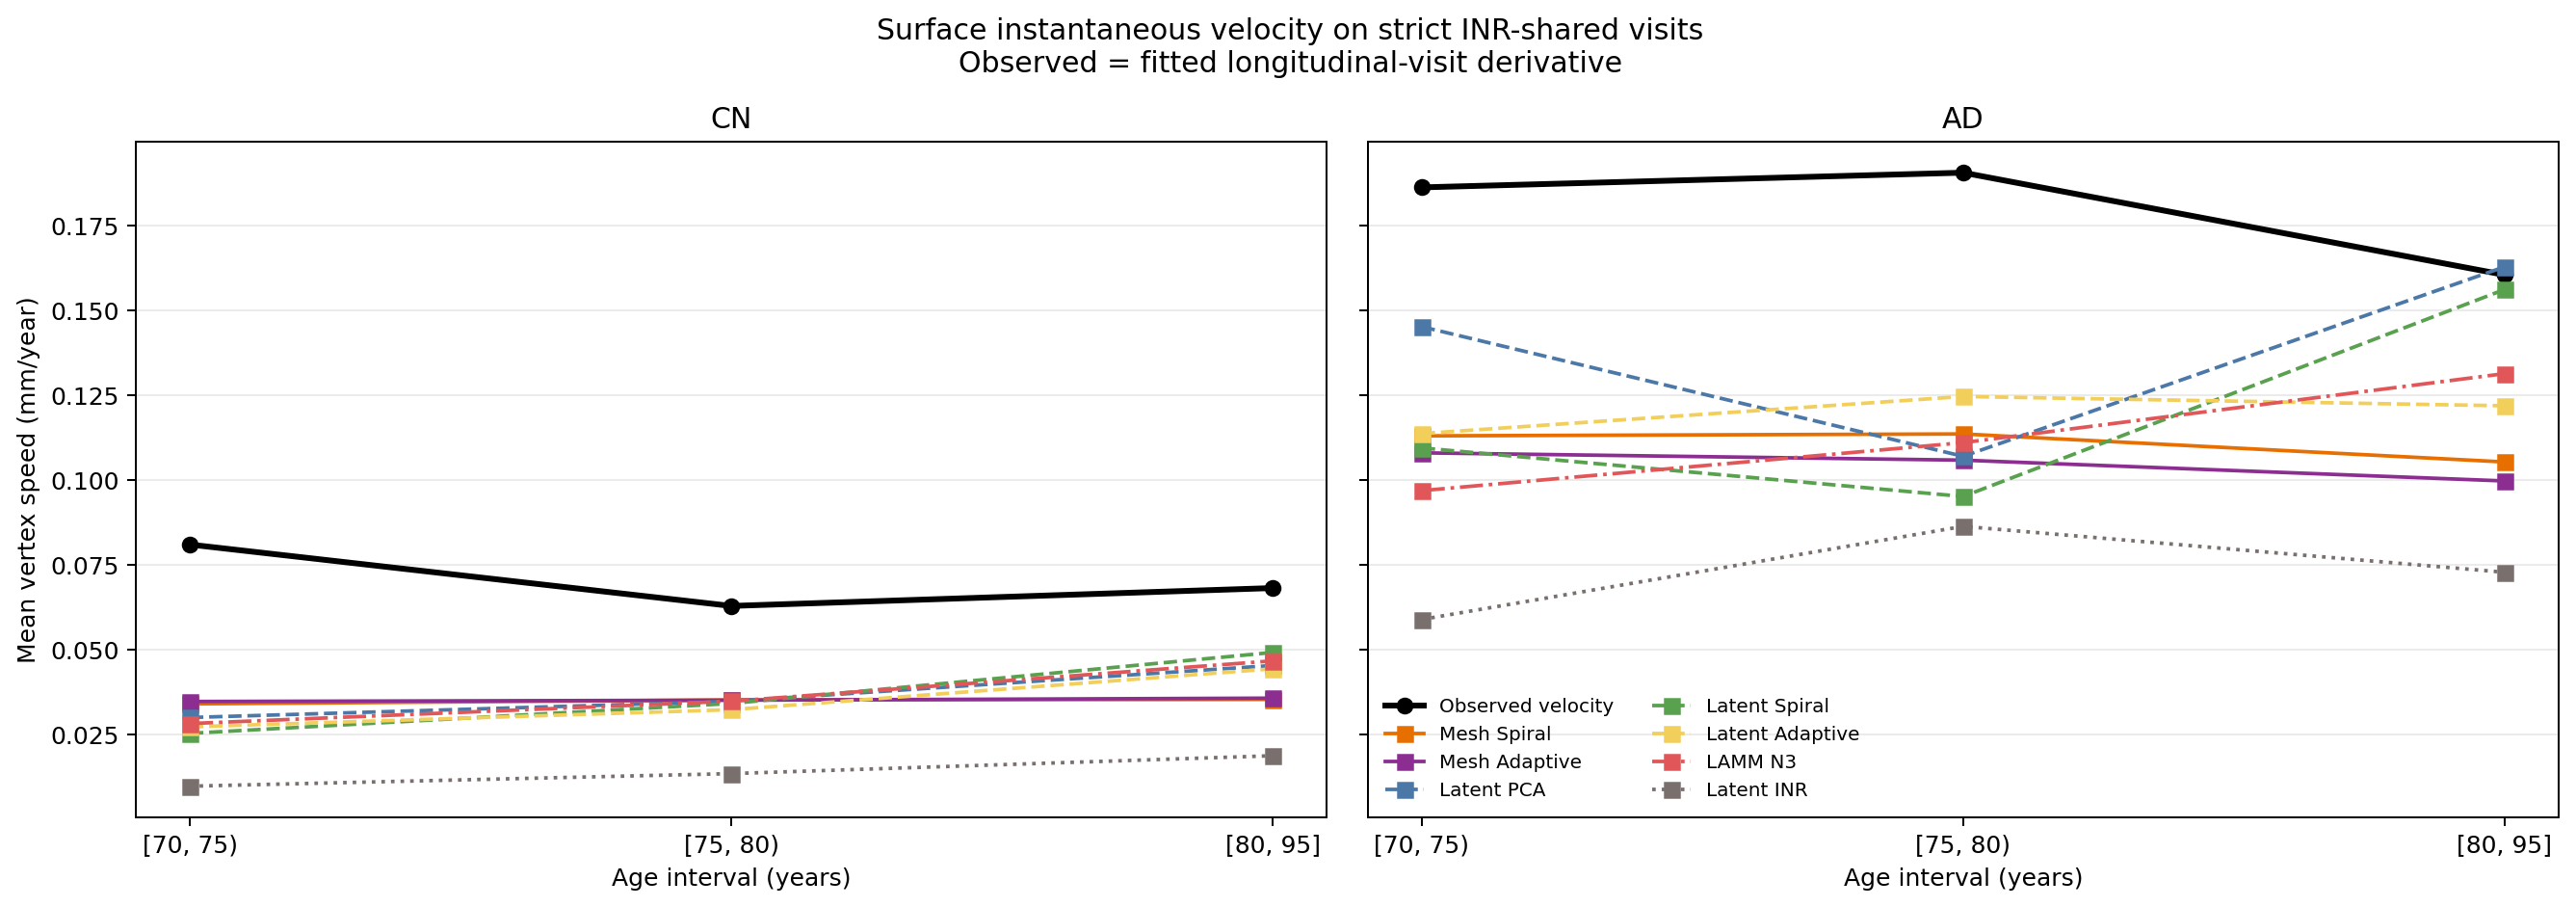

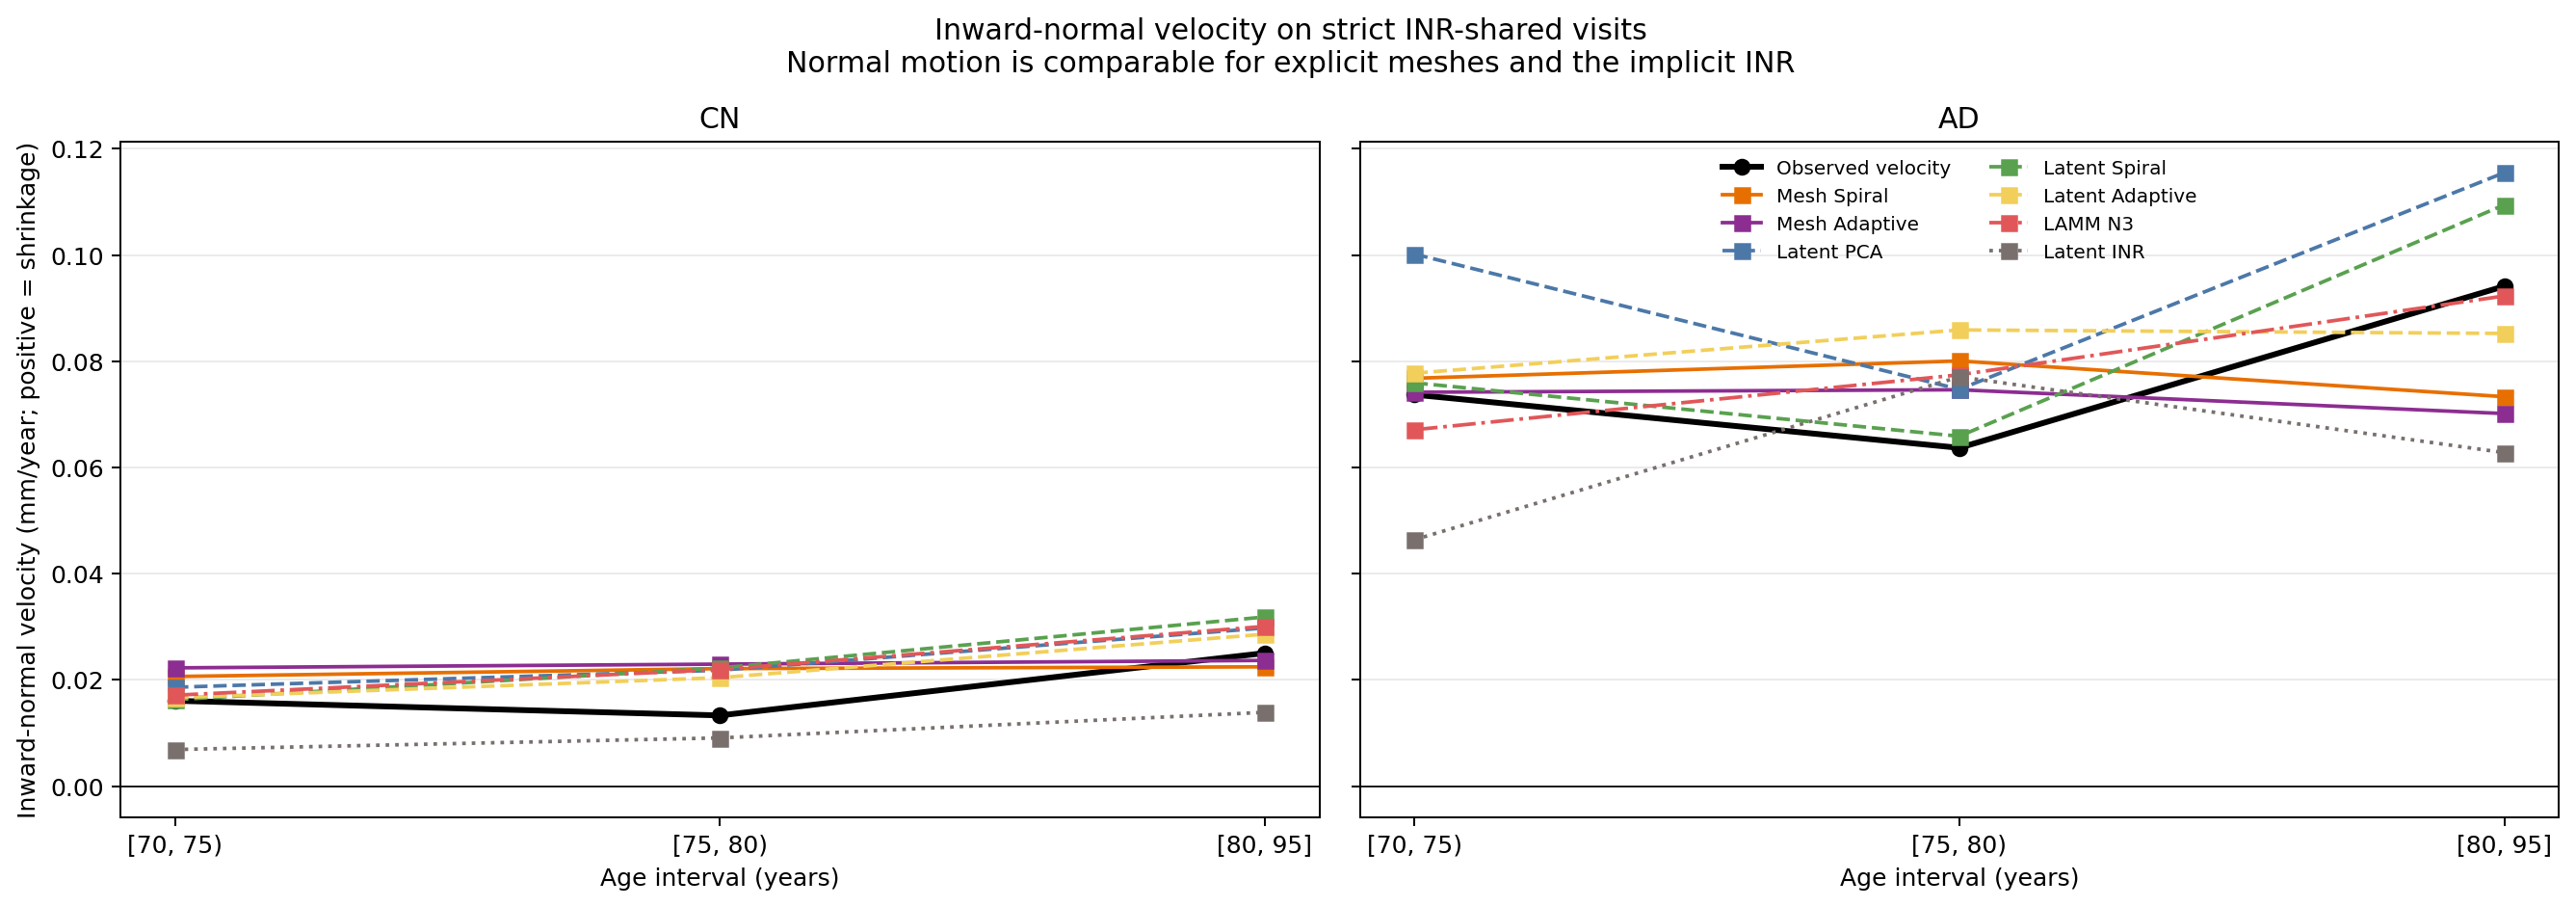

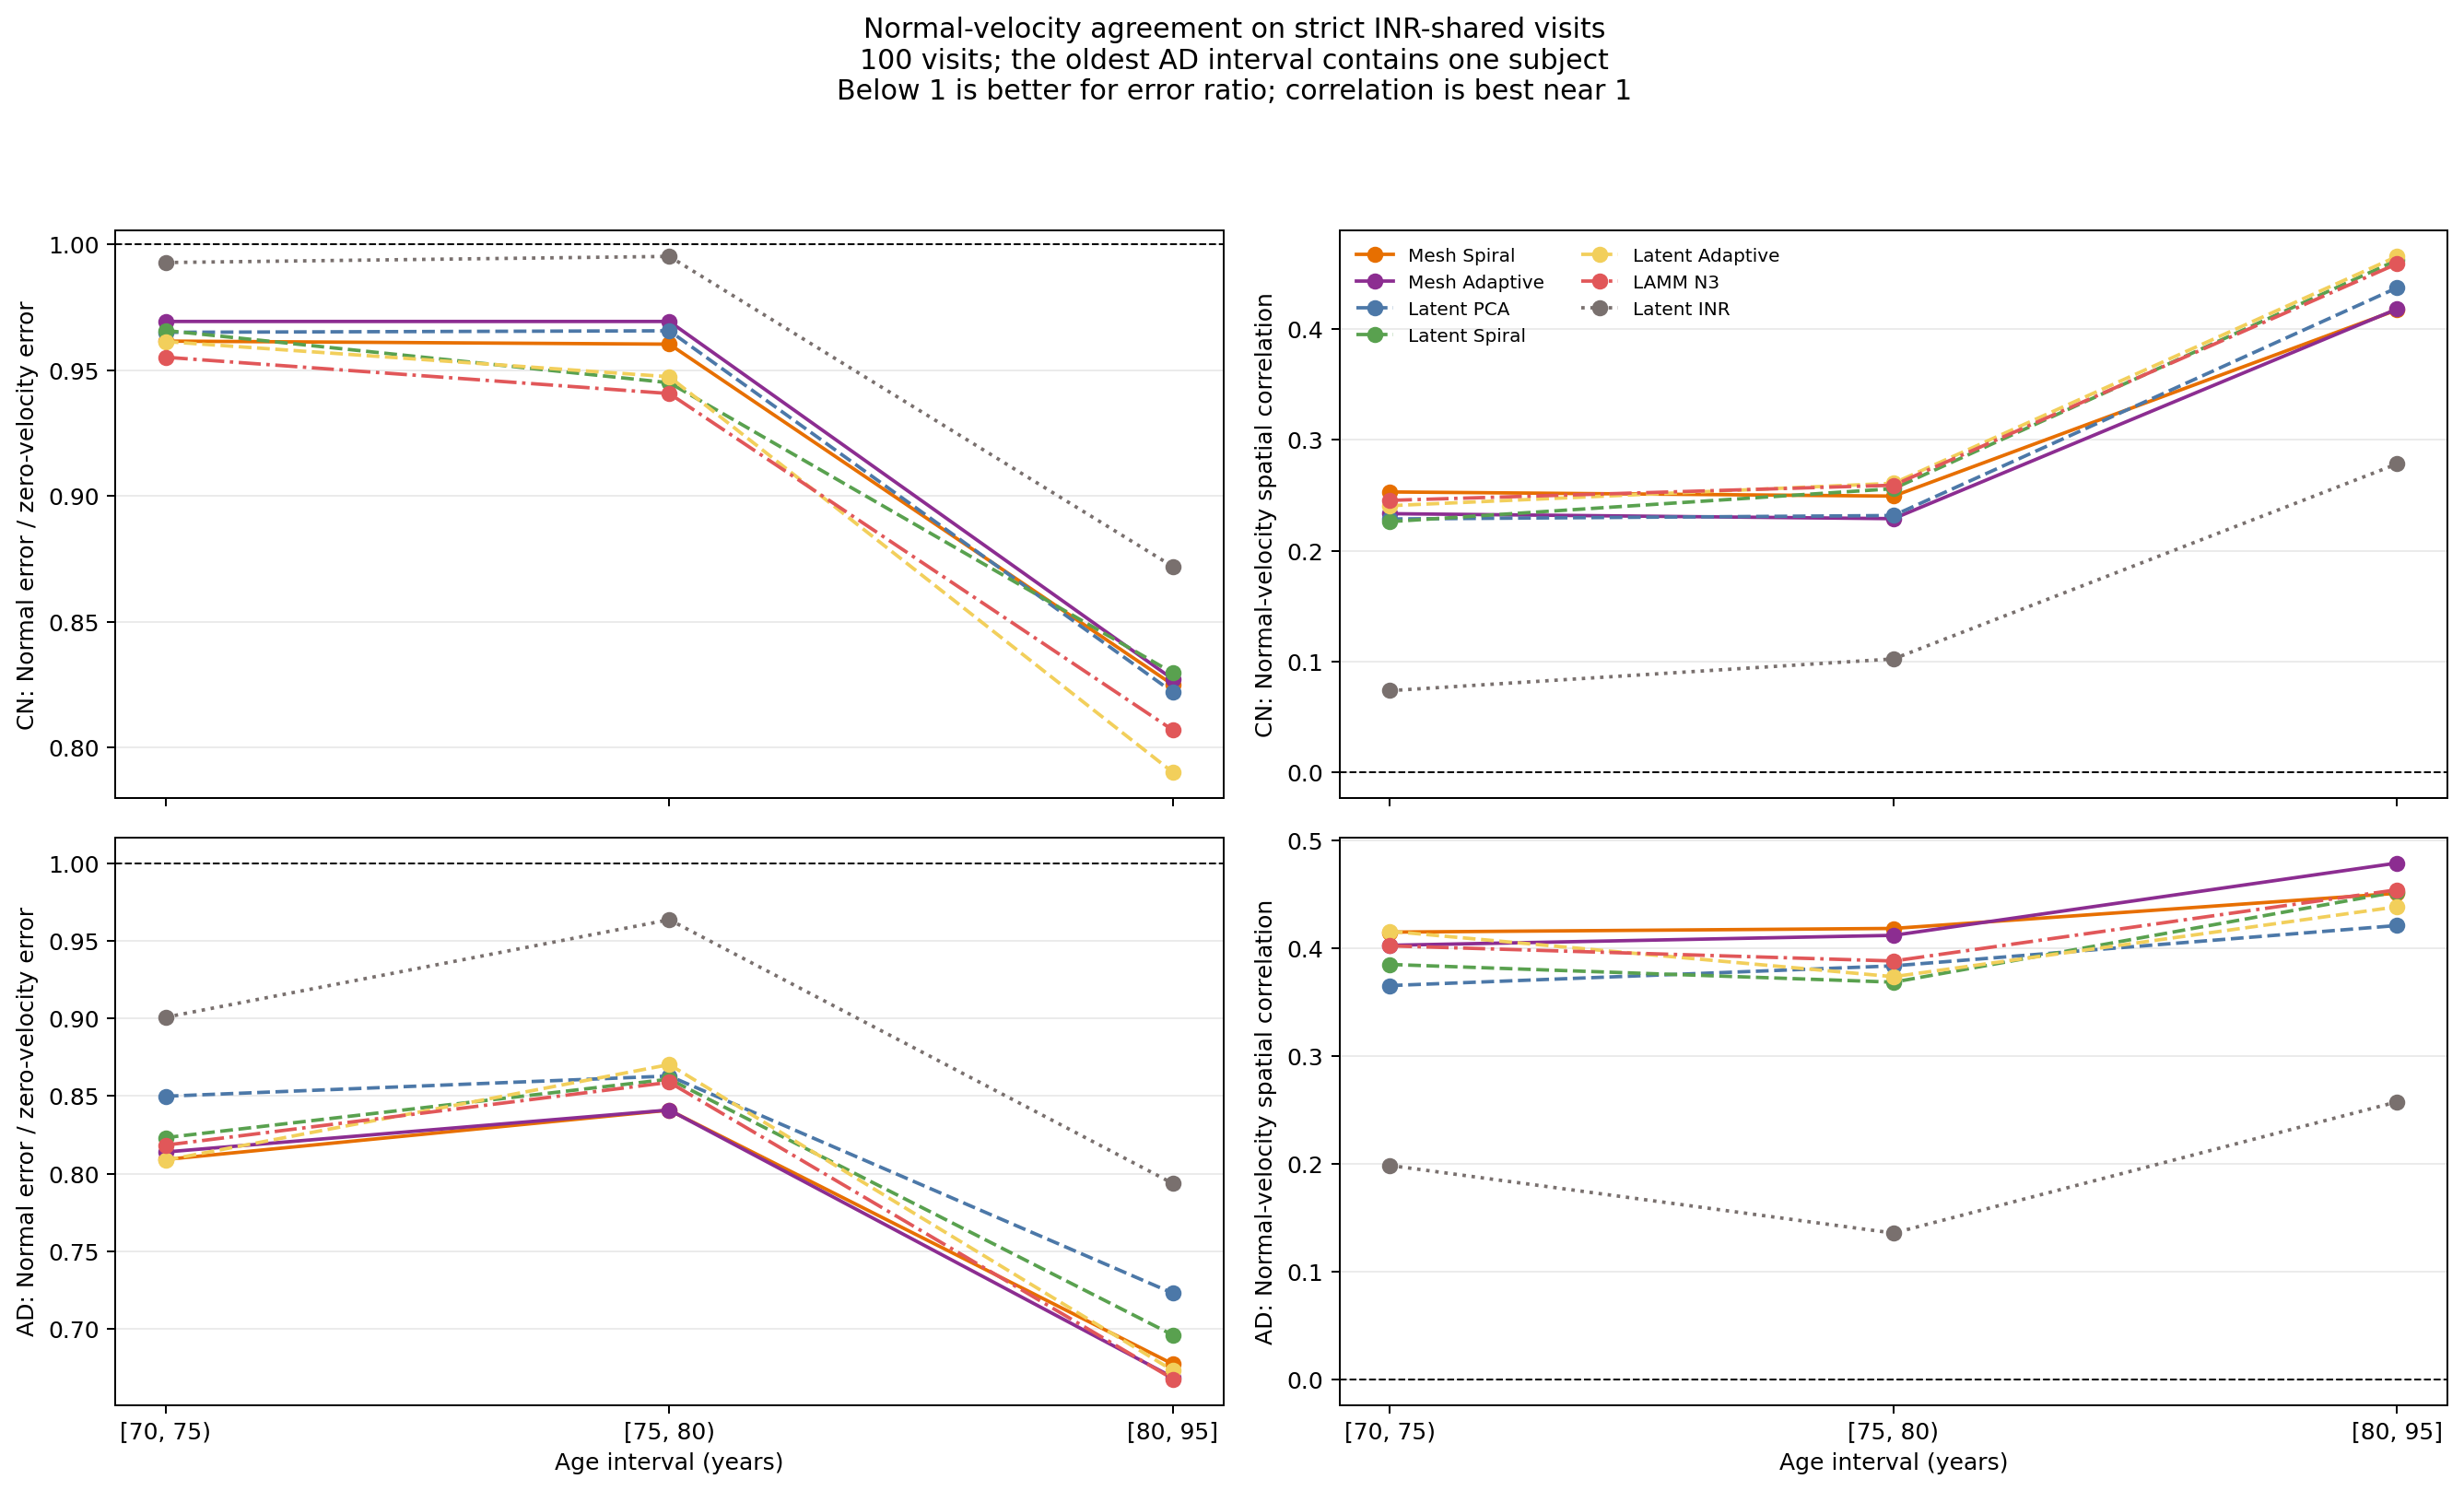

In [7]:
for filename in [
    "strict_common_speed_by_age.png",
    "strict_common_inward_normal_by_age.png",
    "strict_common_normal_agreement_by_age.png",
]:
    display(Image(filename=str(FIGURE_DIR / filename)))


In [8]:
display(strict[cols].rename(columns={
    "method_label": "Method", "diagnosis": "Group", "age_bin": "Age",
    "visits": "Visits", "subjects": "Subjects",
    "predicted_speed_mm_per_year": "Predicted speed",
    "observed_speed_mm_per_year": "Observed speed", "speed_ratio": "Speed ratio",
    "normal_error_to_zero_ratio": "Normal error / zero prediction",
    "normal_pearson": "Normal correlation", "vector_cosine": "Vector cosine",
}).round(4))


,Method,Group,Age,Visits,Subjects,Predicted speed,Observed speed,Speed ratio,Normal error / zero prediction,Normal correlation,Vector cosine
0,Mesh Spiral,CN,"[70, 75)",18,5,0.0339,0.0809,0.4190,0.9615,0.2531,0.3429
1,Mesh Spiral,CN,"[75, 80)",28,8,0.0351,0.0628,0.5584,0.9603,0.2494,0.3220
2,Mesh Spiral,CN,"[80, 95]",22,7,0.0352,0.0680,0.5172,0.8249,0.4174,0.5202
3,Mesh Spiral,AD,"[70, 75)",10,3,0.1129,0.1862,0.6064,0.8092,0.4150,0.5420
4,Mesh Spiral,AD,"[75, 80)",13,4,0.1135,0.1905,0.5956,0.8409,0.4184,0.5129
5,Mesh Spiral,AD,"[80, 95]",4,1,0.1052,0.1604,0.6560,0.6774,0.4510,0.7271
6,Mesh Adaptive,CN,"[70, 75)",18,5,0.0346,0.0809,0.4277,0.9693,0.2335,0.3341
7,Mesh Adaptive,CN,"[75, 80)",28,8,0.0350,0.0628,0.5571,0.9693,0.2290,0.3095
8,Mesh Adaptive,CN,"[80, 95]",22,7,0.0356,0.0680,0.5228,0.8271,0.4183,0.5150
9,Mesh Adaptive,AD,"[70, 75)",10,3,0.1079,0.1862,0.5796,0.8140,0.4027,0.5328


## LAMM N=3 consistency check

The independent implementation is checked against the existing LAMM evaluator.
The maximum absolute discrepancy in surface speed is shown below; a value near
floating-point precision verifies that the correct three checkpoints and
surface-space averaging rule were used.


In [9]:
print(
    "Maximum absolute LAMM N=3 speed difference (mm/year):",
    f'{manifest["lamm_n3_baseline_speed_max_abs_difference"]:.3e}',
)


Maximum absolute LAMM N=3 speed difference (mm/year): 2.536e-08


## Historical ODE and BrainODE comparison — separate protocol

These completed models use a different historical cohort, reference
construction, and evaluation protocol. They are useful as context but must not
be pooled with or ranked directly against the primary matched validation
results. “Observed reference” here therefore refers to that historical
protocol's own fitted longitudinal derivative.


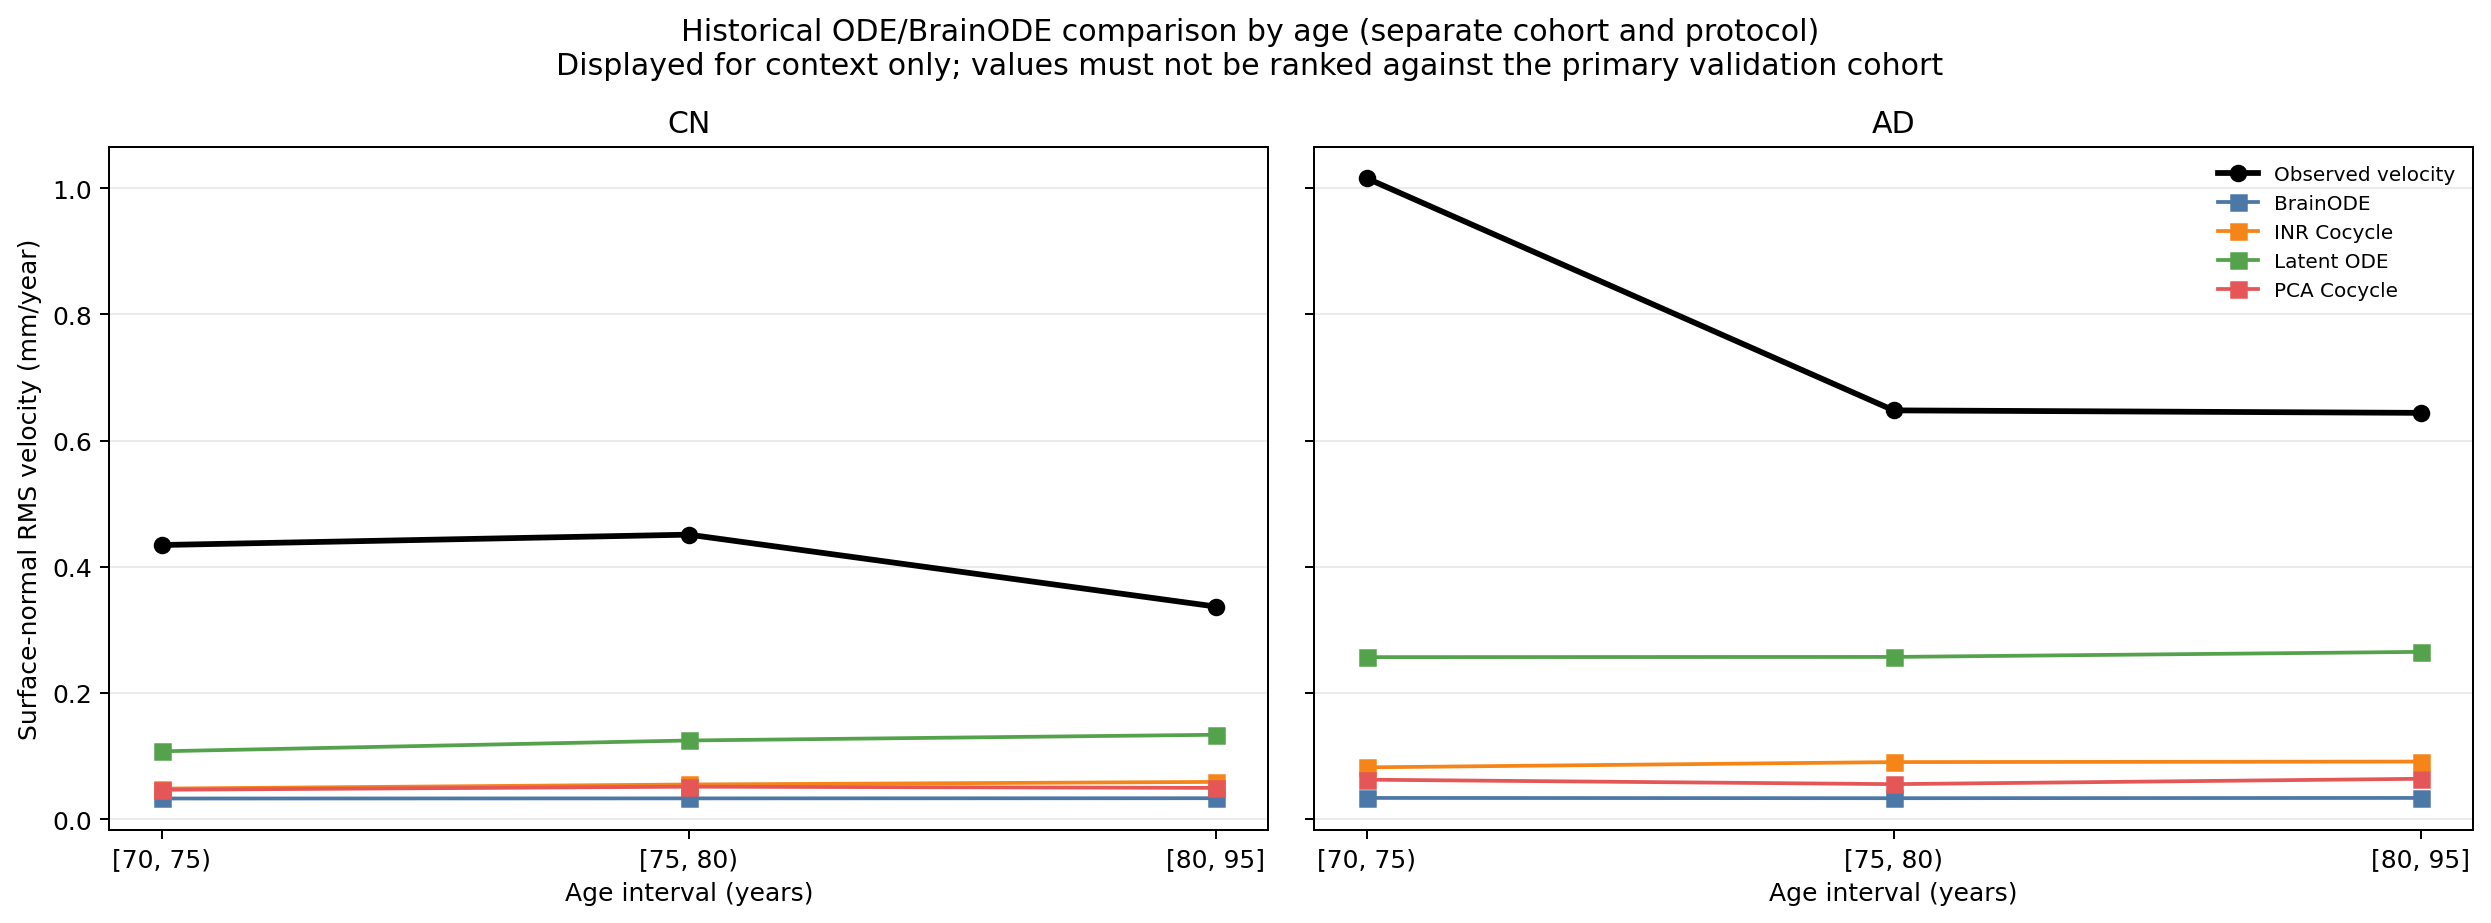

In [10]:
display(Image(filename=str(FIGURE_DIR / "legacy_ode_brainode_velocity_by_age.png")))


In [11]:
display(legacy[cols].rename(columns={
    "method_label": "Method", "diagnosis": "Group", "age_bin": "Age",
    "visits": "Visits", "subjects": "Subjects",
    "predicted_speed_mm_per_year": "Predicted speed",
    "observed_speed_mm_per_year": "Observed speed", "speed_ratio": "Speed ratio",
    "normal_error_to_zero_ratio": "Normal error / zero prediction",
    "normal_pearson": "Normal correlation", "vector_cosine": "Vector cosine",
}).round(4))


,Method,Group,Age,Visits,Subjects,Predicted speed,Observed speed,Speed ratio,Normal error / zero prediction,Normal correlation,Vector cosine
0,BrainODE,CN,"[70, 75)",41,14,0.0330,0.4346,0.0760,0.9950,0.0796,0.0796
1,BrainODE,CN,"[75, 80)",60,20,0.0332,0.4511,0.0736,0.9941,0.1275,0.1275
2,BrainODE,CN,"[80, 95]",39,10,0.0335,0.3371,0.0992,0.9894,0.1309,0.1309
3,BrainODE,AD,"[70, 75)",13,4,0.0339,1.0156,0.0334,0.9991,0.0835,0.0835
4,BrainODE,AD,"[75, 80)",18,7,0.0335,0.6480,0.0517,0.9882,0.1514,0.1514
5,BrainODE,AD,"[80, 95]",27,9,0.0339,0.6440,0.0526,0.9948,0.0581,0.0581
6,INR Cocycle,CN,"[70, 75)",41,14,0.0487,0.4346,0.1121,1.0035,0.0701,0.0701
7,INR Cocycle,CN,"[75, 80)",60,20,0.0552,0.4511,0.1224,1.0055,0.0416,0.0416
8,INR Cocycle,CN,"[80, 95]",39,10,0.0593,0.3371,0.1759,1.0258,-0.0141,-0.0141
9,INR Cocycle,AD,"[70, 75)",13,4,0.0823,1.0156,0.0811,1.0119,-0.0980,-0.0980


## Interpretation limits

The observed reference is inferred from discrete longitudinal visits, so its
quality depends on registration, mesh correspondence, scan interval, and the
trajectory smoother. Age-bin confidence intervals reflect subject sampling,
not uncertainty in every preprocessing step. These results measure whether a
model reproduces the fitted population/subject trajectory field; they do not by
themselves prove a biological mechanism or causal disease effect.
